In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from rw import gw_handler

from matplotlib import rc
from matplotlib  import cm
from matplotlib import gridspec

rc('text', usetex=False)
rc('font', family='serif', size=15)
rc('figure', figsize=(8,6))
rc('axes',linewidth=2)
rc("xtick.major", size=10, width=1.5)
rc("ytick.major", size=10, width=1.5)
rc("xtick", labelsize=15)
rc("ytick", labelsize=15)
rc("xtick.minor", size=10, width=1.2)
rc("ytick.minor", size=10, width=1.2)

# .gw file format info

The `.gw` file is an HDF5-based container designed to store lock-in
acquisition data and associated metadata. It is written by `GwWriter`
and read by `GwReader`.

The format is structured around resonances ("tones") and acquisition
groups. Each acquisition contains I/Q traces, timestamps, counters,
and arbitrary metadata fields.

In [2]:
'''
File Structure
--------------
Root level:

/
├── info/                      (optional)
│   └── <key>: dataset         File-level metadata entries
│
└── tones/
    └── <resonance_label>/
        └── <dataset_index>/
            ├── data/
            │   ├── i           ndarray
            │   ├── q           ndarray
            │   ├── t0          scalar or ndarray
            │   └── counter     scalar or ndarray
            │
            └── info/
                └── <key>: dataset   Per-acquisition metadata

'''
print()

**Groups and Datasets**

`/info`
    Optional group containing general metadata describing the file.
    Keys are user-defined and stored as individual datasets.

`/tones`
    Container for all resonance labels.

`/tones/<resonance_label>`
    Group containing acquisition datasets for a specific resonance.
    The resonance label is typically a string such as "3A", "3B", etc.

`/tones/<resonance_label>/<dataset_index>`
    Acquisition group identified by an integer index stored as string
    ("0", "1", "2", ...).

`/tones/<resonance_label>/<dataset_index>/data`
    Contains numeric acquisition data:

    i : ndarray
        In-phase lock-in samples.
        Shape:
            (N, nsamples)  if multiple acquisitions stored in same group
            (nsamples,)    if single acquisition

    q : ndarray
        Quadrature lock-in samples.
        Same shape as `i`.

    t0 : scalar or ndarray
        Acquisition timestamp(s), expressed in epoch seconds.

    counter : scalar or ndarray
        Acquisition counter(s), typically incremental.


`/tones/<resonance_label>/<dataset_index>/info`
    Contains all metadata fields associated with the acquisition,
    excluding:
        "i", "q", "t0", "counter"

    Typical fields may include:
        LO_frequency
        sampling_rate
        averaging
        experimental parameters
        hardware configuration fields

**Data Semantics**

`Timestamps`
    Stored in epoch seconds (UTC reference).
    Conversion to string format uses "YYYY-MM-DD HH:MM:SS".

`I/Q Units`
    Stored in raw ADC units.
    Conversion to volts is applied at read time:

        If constant conversion is set:
            V = ADC * conversion

        Otherwise:
            V = ADC * cal_func(LO_frequency)

    where `cal_func` is a frequency-dependent interpolation.

**Dataset Indexing:** Each resonance label contains one or more dataset groups
(`<dataset_index>`). A dataset group may itself contain multiple
acquisitions stacked along the first dimension.

# Reader class

In [3]:
# Please, take a look at the documentation for every method.
# Just type: reader.method?
# e.g. reader.get_times?

In [4]:
reader = gw_handler.GwReader("/home/matteo/Scrivania/lavoracci/Bauscia/Data/calib_100Hz_rfsoc/0.05M.gw")

In [5]:
# Return the resonance label in the dataset
reader.get_tones_labels()

['50002',
 '50017',
 '50032',
 '50047',
 '50062',
 '50077',
 '50092',
 '50107',
 '50122',
 '50137',
 '50152',
 '50167',
 '50182',
 '50197',
 '50212',
 '50227']

In [6]:
# Return the dataset indices available for a given resonance label.
# This is not usefull most of the time
resonance_label = "50002"
#==========================
reader.get_tones_loc(Tname=resonance_label)

['0', '1', '2']

In [7]:
# Return the first and last timestamps for a resonance
resonance_label = "50002"
#==========================

tstart, tstop = reader.get_times(Tname=resonance_label,epoch=True,return_tstamps=False)
print("first timestamp:", tstart)
print("last timestamp:", tstop)

#Same results, different format
tstart, tstop = reader.get_times(Tname=resonance_label,epoch=False,return_tstamps=False)
print("first timestamp:", tstart)
print("last timestamp:", tstop)

first timestamp: 1770903474.7692876
last timestamp: 1770903494.3005376
first timestamp: 2026-02-12 13:37:54
last timestamp: 2026-02-12 13:38:14


In [11]:
# The reader can already convert epoch into string, and vice-versa
print(reader._string_to_epoch("2026-02-12 13:37:54"))
print(reader._epoch_to_string(1770903474))

1770903474.0
2026-02-12 13:37:54


In [12]:
# Return resonance datasets.

#This method selects acquisitions whose timestamps `t0` fall within
#`[tstart, tstop]`, loads the corresponding I/Q traces and metadata, and
#merges acquisitions into as few output dictionaries as possible by
#grouping entries with identical metadata (excluding i/q/t0/counter).

# Merging Behavior  When selecting data within a time window:
#- Acquisitions with identical metadata (excluding i, q, t0, counter) are merged into a single output dictionary.
#- Merged data are sorted by timestamp.
#- If metadata differ, separate output entries are returned.

resonance_label = "50002"
#==========================

dic = reader.get_reso_data(Tname=resonance_label)
if len(dic) == 1:
    print("Same metadata for all the output")
    dic = dic[0]

Same metadata for all the output


In [13]:
dic

{'LO_frequency': 50002.0,
 'fir_dec': 468750.0,
 'fs': 262.144,
 'fw_version': 1.0,
 'resonance_frequency': 50002.0,
 't0': array([1.77090347e+09, 1.77090348e+09, 1.77090349e+09]),
 'counter': array([1200468989, 2400468989, 3600468989]),
 'i': array([[ 0.00000000e+00,  0.00000000e+00, -1.11285538e-04, ...,
          4.68512114e-02,  5.36396292e-02,  6.02054759e-02],
        [ 6.65487516e-02,  7.25581706e-02,  7.84563041e-02, ...,
          6.09844747e-02,  5.44186280e-02,  4.78527813e-02],
        [ 4.10643634e-02,  3.43872312e-02,  2.73762423e-02, ...,
         -1.47898480e-01, -1.45895340e-01, -1.43113202e-01]]),
 'q': array([[ 0.        ,  0.        ,  0.        , ...,  0.13587964,
          0.13332007,  0.13020408],
        [ 0.12719937,  0.12352695,  0.11952067, ..., -0.13966335,
         -0.14266806, -0.14533891],
        [-0.14756462, -0.14956776, -0.15112576, ...,  0.04084179,
          0.04740764,  0.0538622 ]])}

`t0` --> (scalar or ndarray) Acquisition timestamp(s), expressed in epoch seconds. t0[i] is the timestamp of the first sample of the i-th row of the "i" or "q" data matrix

`counter` --> (scalar or ndarray) Acquisition counter(s), typically incremental. counter[i] same as t0[i]

`LO_frequency` --> frequency (in Hz) of the lock-in

`fs` --> sampling frequency (in Hz)

`resonance_frequency` --> expected frequency (in Hz) of the resonance

`i (or q)` --> (N,nsamples) or nsamples if single acquisition) In-phase (quadrature phase) lock-in samples.
        

In [24]:
# Return resonance datasets within a specified time window.
# the time window can be in epoch or as string
# see the method documentation

resonance_label = "50002"
t_0 = "2026-02-12 13:37:54"
t_f = np.inf
#==========================

dic = reader.get_reso_data(Tname=resonance_label,tstart = t_0, tstop = t_f)[0]

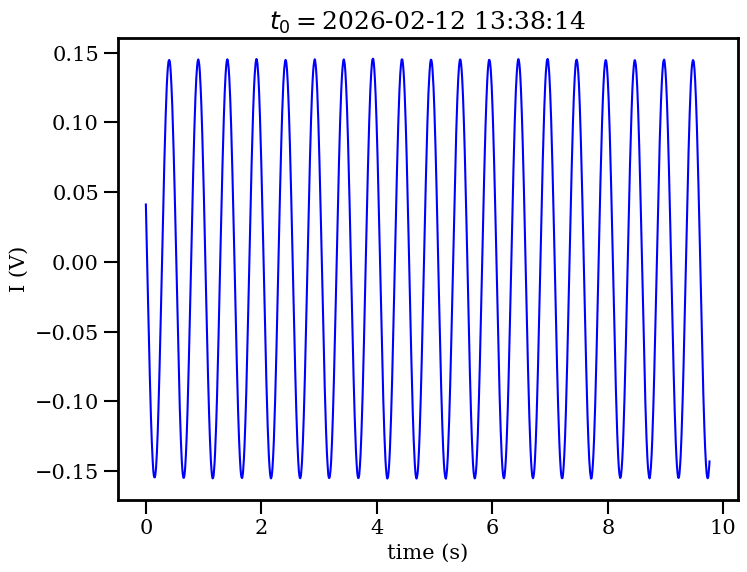

In [25]:
# Plot the n-th acquisition in VOLT

n_sample = 2
#==========================

y = dic["i"][n_sample,:]
x = np.arange(len(y))/dic["fs"]

label = r"$t_0 = $"
label += reader._epoch_to_string(dic["t0"][n_sample])
plt.title(label)
plt.plot(x,y,c="b")
plt.xlabel("time (s)")
plt.ylabel("I (V)")
plt.show()

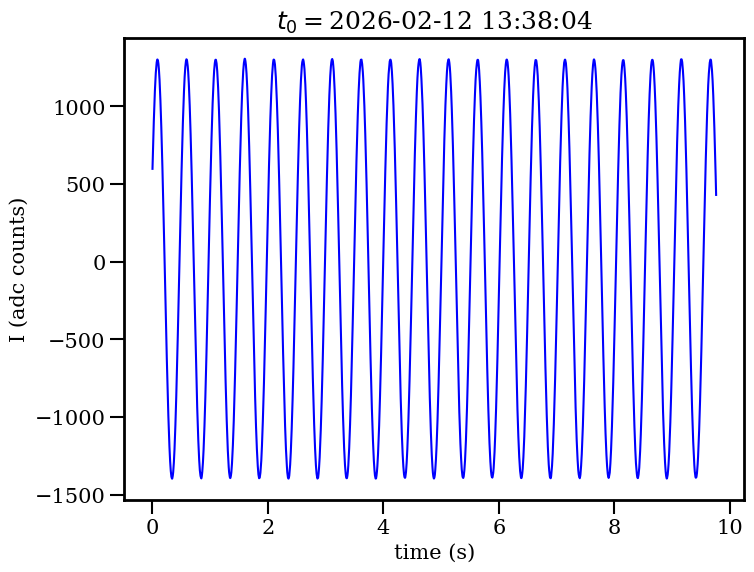

In [26]:
# Plot the n-th acquisition in adc_counts
reader.set_conversion(1)
n_sample = 1
#==========================

dic = reader.get_reso_data(Tname=resonance_label)[0]

y = dic["i"][n_sample,:]
x = np.arange(len(y))/dic["fs"]

label = r"$t_0 = $"
label += reader._epoch_to_string(dic["t0"][n_sample])
plt.title(label)
plt.plot(x,y,c="b")
plt.xlabel("time (s)")
plt.ylabel("I (adc counts)")
plt.show()

reader.set_conversion(None) # Use the default calibration again


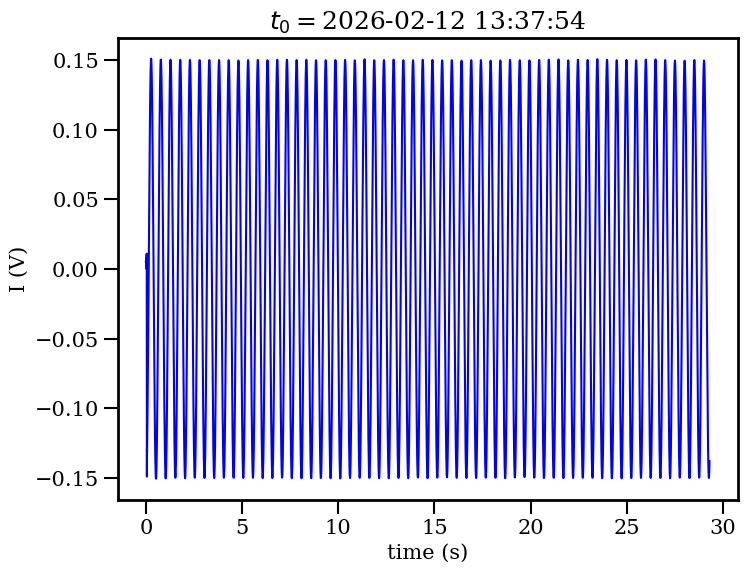

In [27]:
# Given a resonance, plot the full time-trace

resonance_label = "50002"
#==========================

dic = reader.get_reso_data(Tname=resonance_label)[0]

t, z = reader.get_IQ(dic)

label = r"$t_0 = $"
label += reader._epoch_to_string(t[0])
plt.title(label)
plt.plot(t-t[0],np.real(z),c="b")
plt.xlabel("time (s)")
plt.ylabel("I (V)")
plt.show()

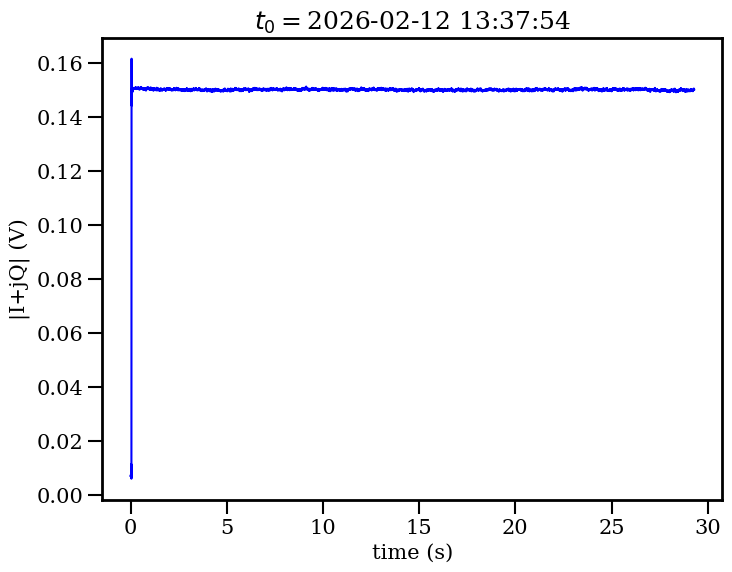

In [28]:
label = r"$t_0 = $"
label += reader._epoch_to_string(t[0])
plt.title(label)
plt.plot(t-t[0],np.abs(z),c="b")
plt.xlabel("time (s)")
plt.ylabel("|I+jQ| (V)")
plt.show()

-----
df : 0.1024  Hz
-----


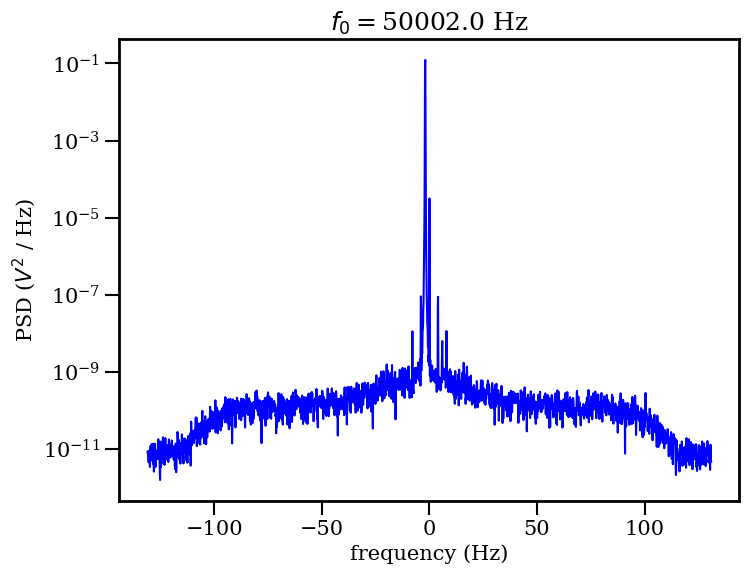

In [29]:
# Given a resonance, plot the PSD of the recorded data

resonance_label = "50002"
#==========================

dic = reader.get_reso_data(Tname=resonance_label)[0]

t, z = reader.get_IQ(dic)


npt = dic["i"].shape[1]
    
f, Pxx_den = signal.welch(z, dic["fs"], nperseg=npt,scaling="density",return_onesided=False,noverlap=0)
print("-----")
print("df :",f[1]-f[0], " Hz")
print("-----")

i_sort =np.argsort(f)

label = r"$f_0 = $"
label += str(dic["LO_frequency"]) + " Hz"
plt.title(label)
plt.plot(f[i_sort],Pxx_den[i_sort],c="b")
plt.xlabel("frequency (Hz)")
plt.ylabel(r"PSD ($V^2$ / Hz)")
#plt.xscale("log")
plt.yscale("log")

plt.show()

# Exercises

In [ ]:
# 1) Select one tone, and load ONLY the last 30 seconds of the dataset.
# 2) Plot the maximum of the PSD for each tones in the .gw file vs the corresponding LO_frequency